In [3]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd

In [4]:
child_data_dir = "../children_data"
adult_data_dir = "../adult_data"

In [5]:
# get averages of any column across all participants in directory
def get_averages(data_directory, column_name, num_rows_to_process):
    files_in_dir = [f for f in os.listdir(data_directory) if f.endswith('.mat')]
    num_files = len(files_in_dir)

    S_matrix = np.full((num_rows_to_process, num_files), np.nan)

    for i, filename in enumerate(files_in_dir):
        file_path = os.path.join(data_directory, filename)
        mat_contents = sio.loadmat(file_path)
        data_column = mat_contents[column_name]

        squeezed_data = data_column.squeeze()
        processed_data = squeezed_data.flatten() if hasattr(squeezed_data, 'flatten') else np.array([squeezed_data])
        
        elements_to_extract = min(len(processed_data), num_rows_to_process)
        S_matrix[:elements_to_extract, i] = processed_data[:elements_to_extract]
            
    N = np.sum(~np.isnan(S_matrix), axis=1)
    std_dev = np.nanstd(S_matrix, axis=1, ddof=1)
    
    sem = np.zeros(num_rows_to_process)
    valid_n_for_sem = N > 1
    sem[valid_n_for_sem] = std_dev[valid_n_for_sem] / np.sqrt(N[valid_n_for_sem])

    S_matrix_for_mean = np.copy(S_matrix)
    S_matrix_for_mean[np.isnan(S_matrix_for_mean)] = 0 
    averages = np.mean(S_matrix_for_mean, axis=1)
            
    return averages, sem

# get all data for all participants in a specific column
def get_all_participant_values(data_dir, column, phase_idx):
    values = []
    for filename in os.listdir(data_dir):
        if filename.endswith('.mat'):
            mat = sio.loadmat(os.path.join(data_dir, filename))
            col = mat[column].squeeze()
            
            if col.ndim > 0 and len(col) > phase_idx:
                values.append(col[phase_idx])
    return np.array(values)

# get data for a specific column and phase index for both child and adult groups
def get_group_data(column, n):
    child_mean, child_sem = get_averages(child_data_dir, column, n)
    adult_mean, adult_sem = get_averages(adult_data_dir, column, n)
    return child_mean[:3], child_sem[:3], adult_mean[:3], adult_sem[:3]

In [6]:
num_rows_to_process = 70

child_avgs, child_sem = get_averages(child_data_dir, "EA", num_rows_to_process)
adult_avgs, adult_sem = get_averages(adult_data_dir, "EA", num_rows_to_process)

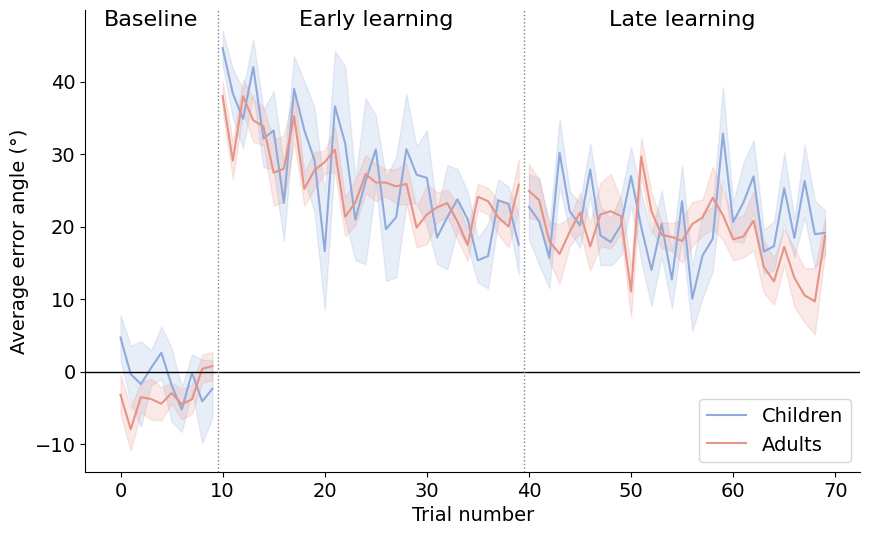

In [9]:
x_indices = np.arange(num_rows_to_process)

# child baseline: 1 - 10
child_segment1_x = x_indices[0:10]
child_segment1_y = child_avgs[0:10]
child_sem_segment1 = child_sem[0:10]
# child early learning: 10 - 40
child_segment2_x = x_indices[10:40]
child_segment2_y = child_avgs[10:40]
child_sem_segment2 = child_sem[10:40]
# child late learning: 40 - 70
child_segment3_x = x_indices[40:70]
child_segment3_y = child_avgs[40:70]
child_sem_segment3 = child_sem[40:70]

# adult baseline: 1 - 10
adult_segment1_x = x_indices[0:10]
adult_segment1_y = adult_avgs[0:10]
adult_sem_segment1 = adult_sem[0:10]
# adult early learning: 10 - 40
adult_segment2_x = x_indices[10:40]
adult_segment2_y = adult_avgs[10:40]
adult_sem_segment2 = adult_sem[10:40]
# adult late learning: 40 - 70
adult_segment3_x = x_indices[40:70]
adult_segment3_y = adult_avgs[40:70]
adult_sem_segment3 = adult_sem[40:70]

child_plot_color = "#8faadc"
adult_plot_color = "#e79385"
alpha_level = 0.2

plt.figure(figsize=(10, 6))

plt.fill_between(child_segment1_x, child_segment1_y - child_sem_segment1, child_segment1_y + child_sem_segment1, color=child_plot_color, alpha=alpha_level, label='_nolegend_')
plt.plot(child_segment1_x, child_segment1_y, label='Children', color=child_plot_color) 
plt.fill_between(child_segment2_x, child_segment2_y - child_sem_segment2, child_segment2_y + child_sem_segment2, color=child_plot_color, alpha=alpha_level, label='_nolegend_')
plt.plot(child_segment2_x, child_segment2_y, color=child_plot_color, label='_nolegend_')
plt.fill_between(child_segment3_x, child_segment3_y - child_sem_segment3, child_segment3_y + child_sem_segment3, color=child_plot_color, alpha=alpha_level, label='_nolegend_')
plt.plot(child_segment3_x, child_segment3_y, color=child_plot_color, label='_nolegend_')

plt.fill_between(adult_segment1_x, adult_segment1_y - adult_sem_segment1, adult_segment1_y + adult_sem_segment1, color=adult_plot_color, alpha=alpha_level, label='_nolegend_')
plt.plot(adult_segment1_x, adult_segment1_y, label='Adults', color=adult_plot_color) 
plt.fill_between(adult_segment2_x, adult_segment2_y - adult_sem_segment2, adult_segment2_y + adult_sem_segment2, color=adult_plot_color, alpha=alpha_level, label='_nolegend_')
plt.plot(adult_segment2_x, adult_segment2_y, color=adult_plot_color, label='_nolegend_')
plt.fill_between(adult_segment3_x, adult_segment3_y - adult_sem_segment3, adult_segment3_y + adult_sem_segment3, color=adult_plot_color, alpha=alpha_level, label='_nolegend_')
plt.plot(adult_segment3_x, adult_segment3_y, color=adult_plot_color, label='_nolegend_')

plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

plt.axvline(x=9.5, color='gray', linestyle=':', linewidth=1)
plt.axvline(x=39.5, color='gray', linestyle=':', linewidth=1)

plt.xlabel('Trial number', fontsize=14)
plt.ylabel('Average error angle (°)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)

plt.text(3, plt.ylim()[1]*1, 'Baseline', ha='center', va='top', fontsize=16)
plt.text(25, plt.ylim()[1]*1, 'Early learning', ha='center', va='top', fontsize=16)
plt.text(55, plt.ylim()[1]*1, 'Late learning', ha='center', va='top', fontsize=16)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

In [10]:
child_meanMT, _ = get_averages(child_data_dir, "meanMT", 5)
adult_meanMT, _ = get_averages(adult_data_dir, "meanMT", 5)
child_meanMT, adult_meanMT

(array([0.96415253, 1.05556403, 1.06038086, 1.02744545, 1.07099568]),
 array([0.98099231, 1.13544401, 1.06668462, 0.98913846, 1.0928702 ]))

In [11]:
child_meanRT, _ = get_averages(child_data_dir, "meanRT", 5)
adult_meanRT, _ = get_averages(adult_data_dir, "meanRT", 5)
child_meanRT, adult_meanRT

(array([0.37469293, 0.3656945 , 0.36623159, 0.35691788, 0.35727118]),
 array([0.26470769, 0.25046506, 0.25462821, 0.26667949, 0.27585977]))

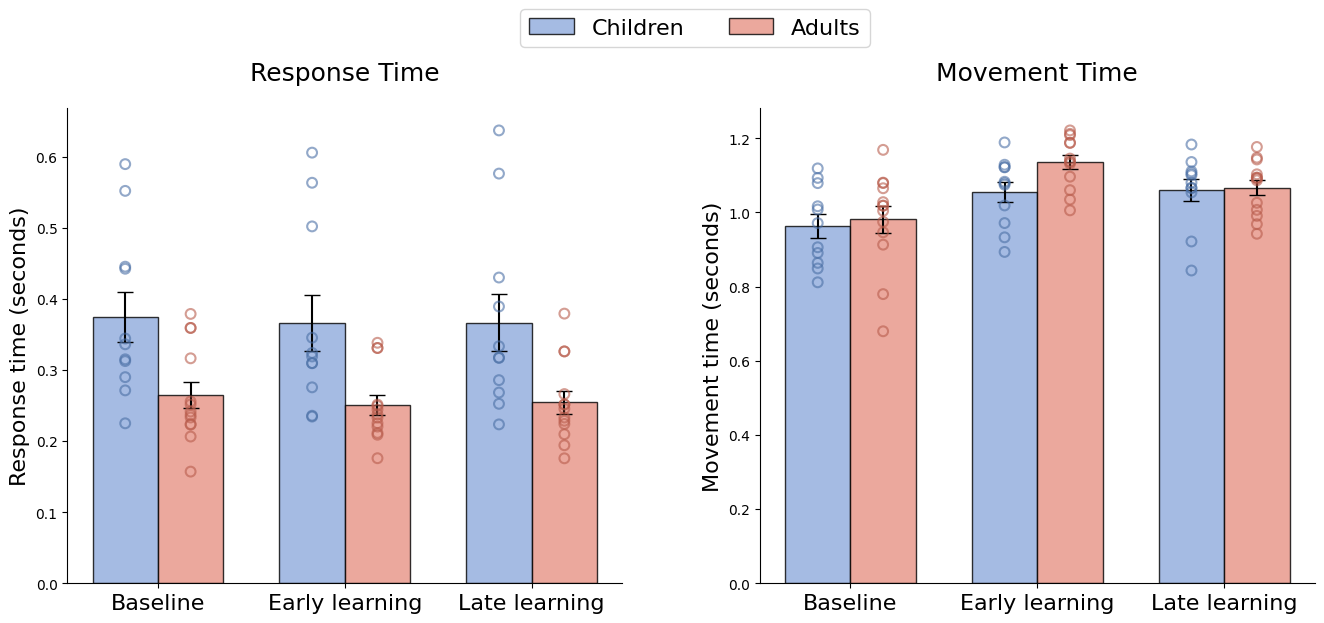

In [12]:
labels = ["Baseline", "Early learning", "Late learning"]
phases = np.arange(len(labels))
width = 0.35

child_mt, child_mt_sem, adult_mt, adult_mt_sem = get_group_data("meanMT", 5)
child_rt, child_rt_sem, adult_rt, adult_rt_sem = get_group_data("meanRT", 5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
plt.subplots_adjust(wspace=20) # spacing between subplots

# response time subplot
ax = axes[0]
bar1 = phases - width/2
bar2 = phases + width/2
bars_rt_child = ax.bar(bar1, child_rt, width, yerr=child_rt_sem, label="Children", color="#8faadc", capsize=6, edgecolor='black', alpha=0.8)
bars_rt_adult = ax.bar(bar2, adult_rt, width, yerr=adult_rt_sem, label="Adults", color="#e79385", capsize=6, edgecolor='black', alpha=0.8)
for i, phase in enumerate(phases):
    child_rt_points = get_all_participant_values(child_data_dir, "meanRT", i)
    adult_rt_points = get_all_participant_values(adult_data_dir, "meanRT", i)
    ax.scatter(np.full(len(child_rt_points), bar1[i]), child_rt_points, facecolors='none', edgecolors="#4a6fa5", s=50, zorder=3, alpha=0.6, linewidths=1.5)
    ax.scatter(np.full(len(adult_rt_points), bar2[i]), adult_rt_points, facecolors='none', edgecolors="#b85c4c", s=50, zorder=3, alpha=0.6, linewidths=1.5)
ax.set_xticks(phases)
ax.set_xticklabels(labels, fontsize=16)
ax.set_ylabel('Response time (seconds)', fontsize=16)
ax.set_title('Response Time', fontsize=18, pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# movement time subplot
ax = axes[1]
bar1 = phases - width/2
bar2 = phases + width/2
bars_mt_child = ax.bar(bar1, child_mt, width, yerr=child_mt_sem, label="Children", color="#8faadc", capsize=6, edgecolor='black', alpha=0.8)
bars_mt_adult = ax.bar(bar2, adult_mt, width, yerr=adult_mt_sem, label="Adults", color="#e79385", capsize=6, edgecolor='black', alpha=0.8)
for i, phase in enumerate(phases):
    child_mt_points = get_all_participant_values(child_data_dir, "meanMT", i)
    adult_mt_points = get_all_participant_values(adult_data_dir, "meanMT", i)
    ax.scatter(np.full(len(child_mt_points), bar1[i]), child_mt_points, facecolors='none', edgecolors="#4a6fa5", s=50, zorder=3, alpha=0.6, linewidths=1.5)
    ax.scatter(np.full(len(adult_mt_points), bar2[i]), adult_mt_points, facecolors='none', edgecolors="#b85c4c", s=50, zorder=3, alpha=0.6, linewidths=1.5)
ax.set_xticks(phases)
ax.set_xticklabels(labels, fontsize=16)
ax.set_ylabel('Movement time (seconds)', fontsize=16)
ax.set_title('Movement Time', fontsize=18, pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# legend
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, fontsize=16, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

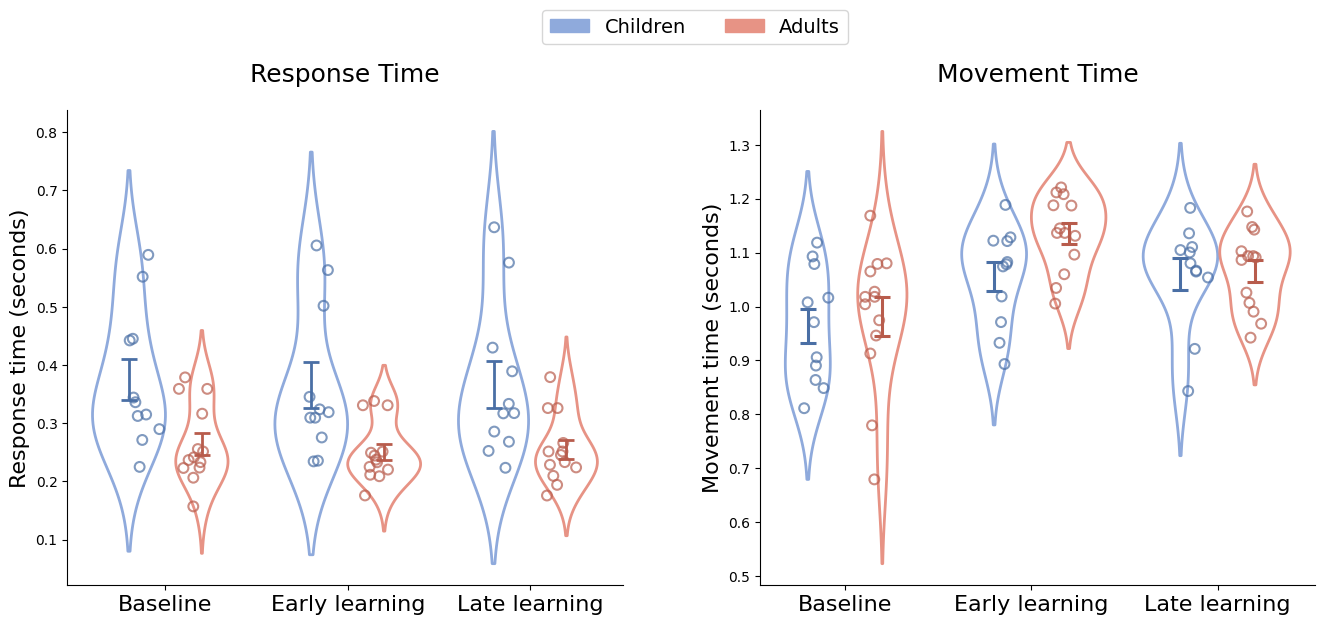

In [13]:
phases = ["Baseline", "Early learning", "Late learning"]
labels = phases
phase_indices = np.arange(len(phases))

# meanMT data
child_mt_all = [get_all_participant_values(child_data_dir, "meanMT", i) for i in range(3)]
adult_mt_all = [get_all_participant_values(adult_data_dir, "meanMT", i) for i in range(3)]
mt_data = []
for i, phase in enumerate(phases):
    for v in child_mt_all[i]:
        mt_data.append({"Group": "Children", "Phase": phase, "Value": v, "PhaseIdx": i})
    for v in adult_mt_all[i]:
        mt_data.append({"Group": "Adults", "Phase": phase, "Value": v, "PhaseIdx": i})
mt_df = pd.DataFrame(mt_data)

# meanRT data
child_rt_all = [get_all_participant_values(child_data_dir, "meanRT", i) for i in range(3)]
adult_rt_all = [get_all_participant_values(adult_data_dir, "meanRT", i) for i in range(3)]
rt_data = []
for i, phase in enumerate(phases):
    for v in child_rt_all[i]:
        rt_data.append({"Group": "Children", "Phase": phase, "Value": v, "PhaseIdx": i})
    for v in adult_rt_all[i]:
        rt_data.append({"Group": "Adults", "Phase": phase, "Value": v, "PhaseIdx": i})
rt_df = pd.DataFrame(rt_data)

# get mean and SEMs for overlay
child_mt, child_mt_sem, adult_mt, adult_mt_sem = get_group_data("meanMT", 5)
child_rt, child_rt_sem, adult_rt, adult_rt_sem = get_group_data("meanRT", 5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
plt.subplots_adjust(wspace=20)

# response time violin plot
sns.violinplot(ax=axes[0], x="Phase", y="Value", hue="Group", data=rt_df, split=False, inner=None, palette=["#8faadc", "#e79385"], fill=False, linewidth=2)
axes[0].set_ylabel("Response time (seconds)", fontsize=16)
axes[0].set_xlabel("")
axes[0].set_title("Response Time", fontsize=18, pad=20)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].legend_.remove()

# scatter points for each group/phase and mean +- SEM bars
for i, phase in enumerate(phases):
    # children
    y = child_rt_all[i]
    x = np.random.normal(i - 0.15, 0.04, size=len(y))  # jitter
    axes[0].scatter(x, y, facecolors='none', edgecolors="#4a6fa5", s=50, zorder=3, alpha=0.7, linewidths=1.5, label=None)
    # adults
    y = adult_rt_all[i]
    x = np.random.normal(i + 0.15, 0.04, size=len(y))
    axes[0].scatter(x, y, facecolors='none', edgecolors="#b85c4c", s=50, zorder=3, alpha=0.7, linewidths=1.5, label=None)
    # mean +- SEM bars
    axes[0].errorbar(i - 0.2, child_rt[i], yerr=child_rt_sem[i], fmt='', color="#4a6fa5", capsize=6, lw=2, capthick=2, label=None, zorder=4)
    axes[0].errorbar(i + 0.2, adult_rt[i], yerr=adult_rt_sem[i], fmt='', color="#b85c4c", capsize=6, lw=2, capthick=2, label=None, zorder=4)
axes[0].set_xticks(phase_indices)
axes[0].set_xticklabels(labels, fontsize=16)

# movement time violin plot
sns.violinplot(ax=axes[1], x="Phase", y="Value", hue="Group", data=mt_df, split=False, inner=None, palette=["#8faadc", "#e79385"], fill=False, linewidth=2)
axes[1].set_ylabel("Movement time (seconds)", fontsize=16)
axes[1].set_xlabel("")
axes[1].set_title("Movement Time", fontsize=18, pad=20)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].legend_.remove()

for i, phase in enumerate(phases):
    # children
    y = child_mt_all[i]
    x = np.random.normal(i - 0.15, 0.04, size=len(y))
    axes[1].scatter(x, y, facecolors='none', edgecolors="#4a6fa5", s=50, zorder=3, alpha=0.7, linewidths=1.5, label=None)
    # adults
    y = adult_mt_all[i]
    x = np.random.normal(i + 0.15, 0.04, size=len(y))
    axes[1].scatter(x, y, facecolors='none', edgecolors="#b85c4c", s=50, zorder=3, alpha=0.7, linewidths=1.5, label=None)
    # mean +- SEM bars
    axes[1].errorbar(i - 0.2, child_mt[i], yerr=child_mt_sem[i], fmt='', color="#4a6fa5", capsize=6, lw=2.2, capthick=2.2, label=None, zorder=4)
    axes[1].errorbar(i + 0.2, adult_mt[i], yerr=adult_mt_sem[i], fmt='', color="#b85c4c", capsize=6, lw=2.2, capthick=2.2, label=None, zorder=4)
axes[1].set_xticks(phase_indices)
axes[1].set_xticklabels(labels, fontsize=16)

# legend
from matplotlib.patches import Patch
custom_legend = [Patch(facecolor="#8faadc", edgecolor="#8faadc", label="blue for children"),
                 Patch(facecolor="#e79385", edgecolor="#e79385", label="red for adults")]
fig.legend(custom_legend, ["Children", "Adults"], fontsize=14, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

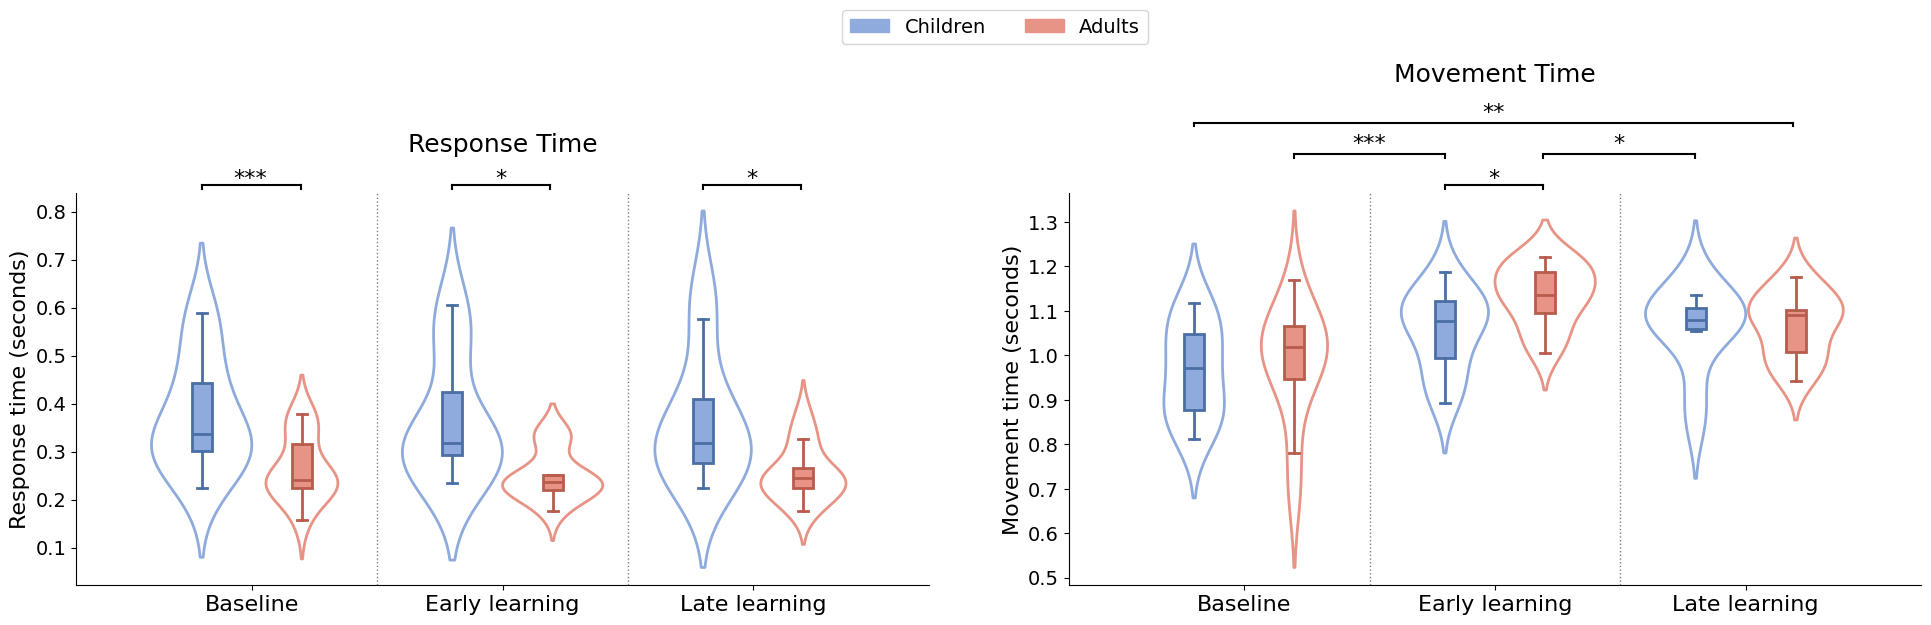

In [ ]:
phases = ["Baseline", "Early learning", "Late learning"]
labels = phases
phase_indices = np.arange(len(phases))

# meanMT data
child_mt_all = [get_all_participant_values(child_data_dir, "meanMT", i) for i in range(3)]
adult_mt_all = [get_all_participant_values(adult_data_dir, "meanMT", i) for i in range(3)]
mt_data = []
for i, phase in enumerate(phases):
    for v in child_mt_all[i]:
        mt_data.append({"Group": "Children", "Phase": phase, "Value": v, "PhaseIdx": i})
    for v in adult_mt_all[i]:
        mt_data.append({"Group": "Adults", "Phase": phase, "Value": v, "PhaseIdx": i})
mt_df = pd.DataFrame(mt_data)

# meanRT data
child_rt_all = [get_all_participant_values(child_data_dir, "meanRT", i) for i in range(3)]
adult_rt_all = [get_all_participant_values(adult_data_dir, "meanRT", i) for i in range(3)]
rt_data = []
for i, phase in enumerate(phases):
    for v in child_rt_all[i]:
        rt_data.append({"Group": "Children", "Phase": phase, "Value": v, "PhaseIdx": i})
    for v in adult_rt_all[i]:
        rt_data.append({"Group": "Adults", "Phase": phase, "Value": v, "PhaseIdx": i})
rt_df = pd.DataFrame(rt_data)

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=False)
plt.subplots_adjust(wspace=20)

# response time violin plot
sns.violinplot(ax=axes[0], x="Phase", y="Value", hue="Group", data=rt_df, split=False, inner=None, palette=["#8faadc", "#e79385"], fill=False, linewidth=2)
axes[0].set_ylabel("Response time (seconds)", fontsize=16)
axes[0].set_xlabel("")
axes[0].set_title("Response Time", fontsize=18, pad=30)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].legend_.remove()

# vertical dotted lines
for i in range(len(phases) - 1):
    axes[0].axvline(x=i + 0.5, color='gray', linestyle=':', linewidth=1)

# boxplots 
box_width = 0.08
for i in range(3):
    # children
    data_c = child_rt_all[i]
    pos_c = i - 0.2
    bplot_c = axes[0].boxplot(data_c, positions=[pos_c], widths=box_width, patch_artist=True,
                              boxprops=dict(facecolor="#8faadc", color="#4a6fa5", linewidth=2),
                              medianprops=dict(color="#4a6fa5", linewidth=2),
                              whiskerprops=dict(color="#4a6fa5", linewidth=2),
                              capprops=dict(color="#4a6fa5", linewidth=2),
                              flierprops=dict(marker='', color="#4a6fa5", alpha=0.3))
    # adults
    data_a = adult_rt_all[i]
    pos_a = i + 0.2
    bplot_a = axes[0].boxplot(data_a, positions=[pos_a], widths=box_width, patch_artist=True,
                              boxprops=dict(facecolor="#e79385", color="#b85c4c", linewidth=2),
                              medianprops=dict(color="#b85c4c", linewidth=2),
                              whiskerprops=dict(color="#b85c4c", linewidth=2),
                              capprops=dict(color="#b85c4c", linewidth=2),
                              flierprops=dict(marker='', color="#b85c4c", alpha=0.3))

axes[0].set_xticks(phase_indices)
axes[0].set_xticklabels(labels, fontsize=16)
axes[0].tick_params(axis='y', labelsize=14)

# Add horizontal line to response time plot
# axes[0].plot([-5, 1], [2, 2], 'k-')

# movement time violin plot
sns.violinplot(ax=axes[1], x="Phase", y="Value", hue="Group", data=mt_df, split=False, inner=None, palette=["#8faadc", "#e79385"], fill=False, linewidth=2)
axes[1].set_ylabel("Movement time (seconds)", fontsize=16)
axes[1].set_xlabel("")
axes[1].set_title("Movement Time", fontsize=18, pad=80)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].legend_.remove()

# vertical dotted lines
for i in range(len(phases) - 1):
    axes[1].axvline(x=i + 0.5, color='gray', linestyle=':', linewidth=1)

# boxplots
for i in range(3):
    # children
    data_c = child_mt_all[i]
    pos_c = i - 0.2
    bplot_c = axes[1].boxplot(data_c, positions=[pos_c], widths=box_width, patch_artist=True,
                              boxprops=dict(facecolor="#8faadc", color="#4a6fa5", linewidth=2),
                              medianprops=dict(color="#4a6fa5", linewidth=2),
                              whiskerprops=dict(color="#4a6fa5", linewidth=2),
                              capprops=dict(color="#4a6fa5", linewidth=2),
                              flierprops=dict(marker='', color="#4a6fa5", alpha=0.3))
    # adults
    data_a = adult_mt_all[i]
    pos_a = i + 0.2
    bplot_a = axes[1].boxplot(data_a, positions=[pos_a], widths=box_width, patch_artist=True,
                              boxprops=dict(facecolor="#e79385", color="#b85c4c", linewidth=2),
                              medianprops=dict(color="#b85c4c", linewidth=2),
                              whiskerprops=dict(color="#b85c4c", linewidth=2),
                              capprops=dict(color="#b85c4c", linewidth=2),
                              flierprops=dict(marker='', color="#b85c4c", alpha=0.3))

axes[1].set_xticks(phase_indices)
axes[1].set_xticklabels(labels, fontsize=16)
axes[1].tick_params(axis='y', labelsize=14)

from matplotlib.patches import Patch
custom_legend = [Patch(facecolor="#8faadc", edgecolor="#8faadc", label="Children"),
                 Patch(facecolor="#e79385", edgecolor="#e79385", label="Adults")]
fig.legend(custom_legend, ["Children", "Adults"], fontsize=14, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Significance bars
# RESPONSE TIME

x_left_0 = 0.735
x_right_0 = 0.85
y_top_0 = 1.02
y_bottom_0 = 1.01

# For axes[0]
axes[0].add_line(plt.Line2D([x_left_0, x_right_0], [y_top_0, y_top_0], transform=axes[0].transAxes, color='k', clip_on=False))
axes[0].add_line(plt.Line2D([x_left_0, x_left_0], [y_top_0, y_bottom_0], transform=axes[0].transAxes, color='k', clip_on=False))
axes[0].add_line(plt.Line2D([x_right_0, x_right_0], [y_top_0, y_bottom_0], transform=axes[0].transAxes, color='k', clip_on=False))
axes[0].text(0.7925, 1.01, "*", fontsize=16, ha='center', va='bottom', transform=axes[0].transAxes)

x_left_2 = 0.441
x_right_2 = 0.556
y_top_2 = 1.02
y_bottom_2 = 1.01

# For axes[0]
axes[0].add_line(plt.Line2D([x_left_2, x_right_2], [y_top_2, y_top_2], transform=axes[0].transAxes, color='k', clip_on=False))
axes[0].add_line(plt.Line2D([x_left_2, x_left_2], [y_top_2, y_bottom_2], transform=axes[0].transAxes, color='k', clip_on=False))
axes[0].add_line(plt.Line2D([x_right_2, x_right_2], [y_top_2, y_bottom_2], transform=axes[0].transAxes, color='k', clip_on=False))
axes[0].text(0.4985, 1.01, "*", fontsize=16, ha='center', va='bottom', transform=axes[0].transAxes)

x_left_3 = 0.147
x_right_3 = 0.264
y_top_3 = 1.02
y_bottom_3 = 1.01

# For axes[0]
axes[0].add_line(plt.Line2D([x_left_3, x_right_3], [y_top_3, y_top_3], transform=axes[0].transAxes, color='k', clip_on=False))
axes[0].add_line(plt.Line2D([x_left_3, x_left_3], [y_top_3, y_bottom_3], transform=axes[0].transAxes, color='k', clip_on=False))
axes[0].add_line(plt.Line2D([x_right_3, x_right_3], [y_top_3, y_bottom_3], transform=axes[0].transAxes, color='k', clip_on=False))
axes[0].text(0.2045, 1.01, "***", fontsize=16, ha='center', va='bottom', transform=axes[0].transAxes)

# MOVEMENT TIME

x_left_4 = 0.441
x_right_4 = 0.556
y_top_4 = 1.02
y_bottom_4 = 1.01

# For axes[0]
axes[1].add_line(plt.Line2D([x_left_4, x_right_4], [y_top_4, y_top_4], transform=axes[1].transAxes, color='k', clip_on=False))
axes[1].add_line(plt.Line2D([x_left_4, x_left_4], [y_top_4, y_bottom_4], transform=axes[1].transAxes, color='k', clip_on=False))
axes[1].add_line(plt.Line2D([x_right_4, x_right_4], [y_top_4, y_bottom_4], transform=axes[1].transAxes, color='k', clip_on=False))
axes[1].text(0.4985, 1.01, "*", fontsize=16, ha='center', va='bottom', transform=axes[1].transAxes)

x_left_1 = 0.264
x_right_1 = 0.441
y_top_1 = 1.1
y_bottom_1 = 1.09

# For axes[1]
axes[1].add_line(plt.Line2D([x_left_1, x_right_1], [y_top_1, y_top_1], transform=axes[1].transAxes, color='k', clip_on=False))
axes[1].add_line(plt.Line2D([x_left_1, x_left_1], [y_top_1, y_bottom_1], transform=axes[1].transAxes, color='k', clip_on=False))
axes[1].add_line(plt.Line2D([x_right_1, x_right_1], [y_top_1, y_bottom_1], transform=axes[1].transAxes, color='k', clip_on=False))
axes[1].text(0.352, 1.1, "***", fontsize=16, ha='center', va='bottom', transform=axes[1].transAxes)

x_left_5 = 0.556
x_right_5 = 0.735
y_top_5 = 1.1
y_bottom_5 = 1.09

# For axes[1]
axes[1].add_line(plt.Line2D([x_left_5, x_right_5], [y_top_5, y_top_5], transform=axes[1].transAxes, color='k', clip_on=False))
axes[1].add_line(plt.Line2D([x_left_5, x_left_5], [y_top_5, y_bottom_5], transform=axes[1].transAxes, color='k', clip_on=False))
axes[1].add_line(plt.Line2D([x_right_5, x_right_5], [y_top_5, y_bottom_5], transform=axes[1].transAxes, color='k', clip_on=False))
axes[1].text(0.6455, 1.1, "*", fontsize=16, ha='center', va='bottom', transform=axes[1].transAxes)

x_left_6 = 0.147
x_right_6 = 0.85
y_top_6 = 1.18
y_bottom_6 = 1.17

# For axes[1]
axes[1].add_line(plt.Line2D([x_left_6, x_right_6], [y_top_6, y_top_6], transform=axes[1].transAxes, color='k', clip_on=False))
axes[1].add_line(plt.Line2D([x_left_6, x_left_6], [y_top_6, y_bottom_6], transform=axes[1].transAxes, color='k', clip_on=False))
axes[1].add_line(plt.Line2D([x_right_6, x_right_6], [y_top_6, y_bottom_6], transform=axes[1].transAxes, color='k', clip_on=False))
axes[1].text(0.4985, 1.18, "**", fontsize=16, ha='center', va='bottom', transform=axes[1].transAxes)

plt.show()